In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HDFS Query") \
    .master("local[*]") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/14 15:24:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df = spark.read.csv(
    "hdfs://namenode:9000/spark_data/hotel_bookings_preprocessed.csv",
    header=True,
    inferSchema=True
)
df.show()

26/06/14 15:24:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+--------------------+-------------+------+---------------------------+-------------------------+------------+------------+--------------------+---------+-------------------+-----------------+
|       hotel|is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|days_in_waiting_list|customer_type| 

In [3]:
df.printSchema()

root
 |-- hotel: string (nullable = true)
 |-- is_canceled: integer (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- arrival_date_year: integer (nullable = true)
 |-- arrival_date_month: string (nullable = true)
 |-- arrival_date_week_number: integer (nullable = true)
 |-- arrival_date_day_of_month: integer (nullable = true)
 |-- stays_in_weekend_nights: integer (nullable = true)
 |-- stays_in_week_nights: integer (nullable = true)
 |-- adults: integer (nullable = true)
 |-- children: integer (nullable = true)
 |-- babies: integer (nullable = true)
 |-- meal: string (nullable = true)
 |-- country: string (nullable = true)
 |-- market_segment: string (nullable = true)
 |-- distribution_channel: string (nullable = true)
 |-- is_repeated_guest: integer (nullable = true)
 |-- previous_cancellations: integer (nullable = true)
 |-- previous_bookings_not_canceled: integer (nullable = true)
 |-- reserved_room_type: string (nullable = true)
 |-- assigned_room_type: string (nulla

In [3]:
df.createOrReplaceTempView("hotel_bookings")

## 1. Tỷ lệ hủy đặt phòng và xu hướng qua từng năm

In [ ]:
spark.sql("""
WITH yearly_cancel AS
(
    SELECT
        arrival_date_year,
        ROUND(AVG(is_canceled)*100,2) cancel_rate
    FROM hotel_bookings
    GROUP BY arrival_date_year
)
SELECT
    arrival_date_year,
    cancel_rate,
    LAG(cancel_rate)
        OVER(ORDER BY arrival_date_year)
        AS previous_year,
    cancel_rate - LAG(cancel_rate) OVER(ORDER BY arrival_date_year) AS change_rate
FROM yearly_cancel;
""").show()

26/06/13 04:53:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 04:53:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 04:53:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 04:53:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 04:53:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 04:53:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 0

+-----------------+-----------+-------------+-------------------+
|arrival_date_year|cancel_rate|previous_year|        change_rate|
+-----------------+-----------+-------------+-------------------+
|             2015|      37.26|         NULL|               NULL|
|             2016|      36.12|        37.26|-1.1400000000000006|
|             2017|      38.81|        36.12|  2.690000000000005|
+-----------------+-----------+-------------+-------------------+



26/06/14 15:26:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 15:26:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 15:26:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 15:26:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 15:26:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 15:26:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 1

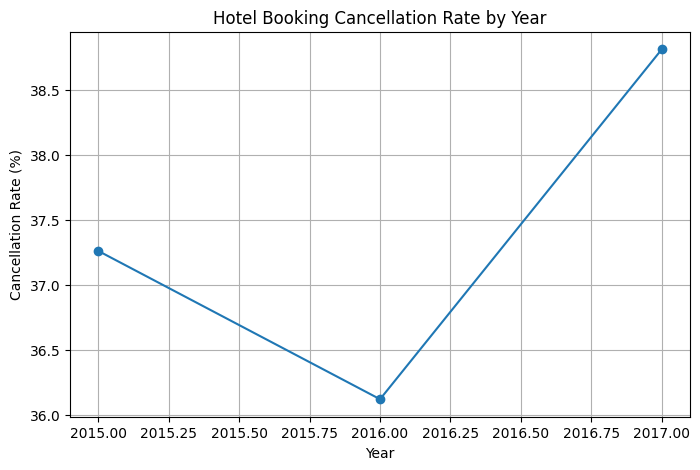

In [6]:
result = spark.sql("""
WITH yearly_cancel AS
(
    SELECT
        arrival_date_year,
        ROUND(AVG(is_canceled)*100,2) cancel_rate
    FROM hotel_bookings
    GROUP BY arrival_date_year
)
SELECT
    arrival_date_year,
    cancel_rate,
    LAG(cancel_rate)
        OVER(ORDER BY arrival_date_year)
        AS previous_year,
    cancel_rate - LAG(cancel_rate) OVER(ORDER BY arrival_date_year) AS change_rate
FROM yearly_cancel;
""")

pdf = result.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(
    pdf['arrival_date_year'],
    pdf['cancel_rate'],
    marker='o'
)

plt.title('Hotel Booking Cancellation Rate by Year')
plt.xlabel('Year')
plt.ylabel('Cancellation Rate (%)')
plt.grid(True)

plt.show()

## 3. Top 5 quốc gia đặt phòng nhiều nhất trong từng loại khách sạn

In [ ]:
spark.sql("""
WITH country_booking AS
(
    SELECT
        hotel,
        country,
        COUNT(*) total_booking
    FROM hotel_bookings
    WHERE country IS NOT NULL
    GROUP BY hotel,country
)
SELECT *
FROM
(
    SELECT *,
           ROW_NUMBER()
           OVER
           (
               PARTITION BY hotel
               ORDER BY total_booking DESC
           ) rn
    FROM country_booking
) x
WHERE rn <= 5;
""").show()

+------------+-------+-------------+---+
|       hotel|country|total_booking| rn|
+------------+-------+-------------+---+
|  City Hotel|    PRT|        30592|  1|
|  City Hotel|    FRA|         8761|  2|
|  City Hotel|    DEU|         6068|  3|
|  City Hotel|    GBR|         5285|  4|
|  City Hotel|    ESP|         4588|  5|
|Resort Hotel|    PRT|        17289|  1|
|Resort Hotel|    GBR|         6793|  2|
|Resort Hotel|    ESP|         3942|  3|
|Resort Hotel|    IRL|         2165|  4|
|Resort Hotel|    FRA|         1603|  5|
+------------+-------+-------------+---+



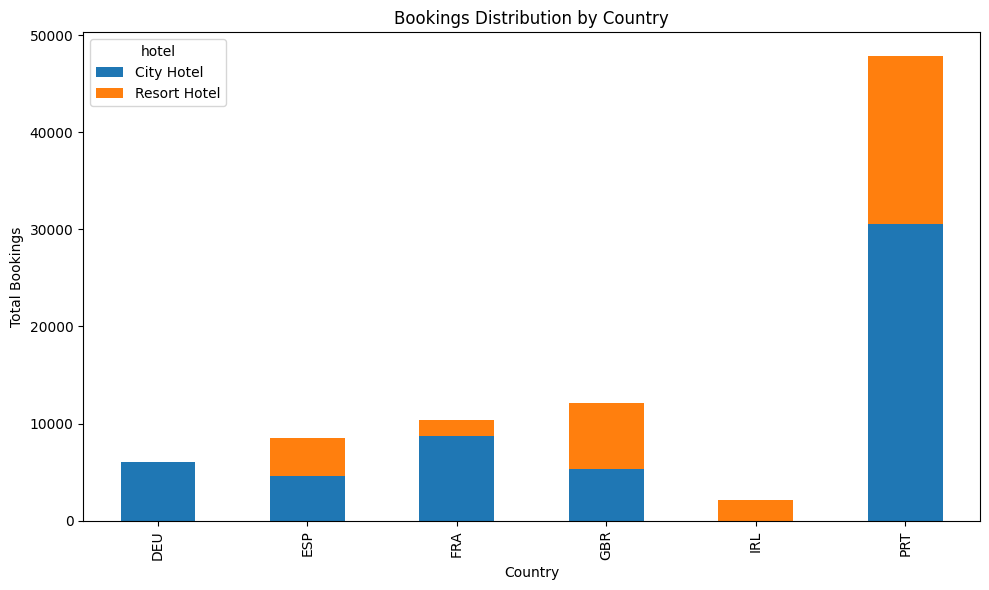

In [12]:
result = spark.sql("""
WITH country_booking AS
(
    SELECT
        hotel,
        country,
        COUNT(*) total_booking
    FROM hotel_bookings
    WHERE country IS NOT NULL
    GROUP BY hotel,country
)
SELECT *
FROM
(
    SELECT *,
           ROW_NUMBER()
           OVER
           (
               PARTITION BY hotel
               ORDER BY total_booking DESC
           ) rn
    FROM country_booking
) x
WHERE rn <= 5;
""")

pdf = result.toPandas()

import matplotlib.pyplot as plt
import pandas as pd

pivot_df = pdf.pivot(
    index='country',
    columns='hotel',
    values='total_booking'
).fillna(0)

# pivot_df.plot(
#     kind='bar',
#     figsize=(10,6)
# )

# plt.title('Total Bookings by Country and Hotel Type')
# plt.xlabel('Country')
# plt.ylabel('Total Bookings')
# plt.xticks(rotation=45)
# plt.legend(title='Hotel Type')
# plt.tight_layout()

# plt.show()

pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Bookings Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Total Bookings')

plt.tight_layout()
plt.show()

## 5. Mùa có lượng đặt phòng cao nhất của từng năm

In [10]:
spark.sql("""
WITH season_booking AS
(
SELECT
    arrival_date_year,
    CASE
      WHEN arrival_date_month IN ('December','January','February') THEN 'Winter'
      WHEN arrival_date_month IN ('March','April','May') THEN 'Spring'
      WHEN arrival_date_month IN ('June','July','August') THEN 'Summer'
      ELSE 'Autumn'
    END season,
    COUNT(*) total_booking
FROM hotel_bookings
GROUP BY arrival_date_year, season
)

SELECT *
FROM (
        SELECT *, RANK() OVER (
        PARTITION BY arrival_date_year 
        ORDER BY total_booking DESC
        ) rnk 
        FROM season_booking) x
WHERE rnk=1;
""").show()

+-----------------+------+-------------+---+
|arrival_date_year|season|total_booking|rnk|
+-----------------+------+-------------+---+
|             2015|Autumn|        12308|  1|
|             2016|Autumn|        15895|  1|
|             2017|Spring|        16844|  1|
+-----------------+------+-------------+---+



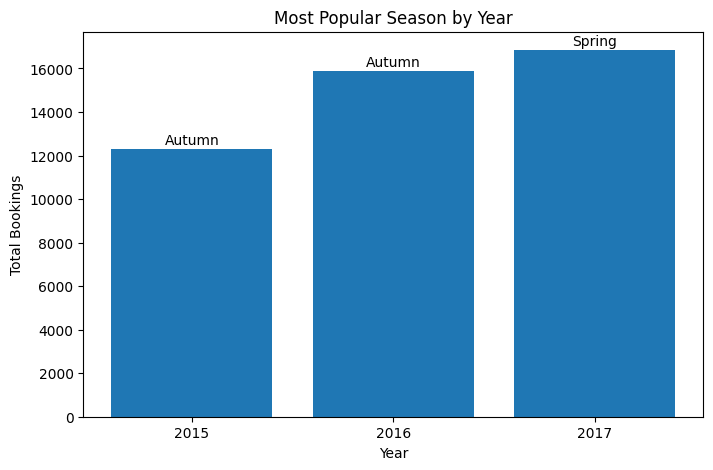

In [13]:
import matplotlib.pyplot as plt

result = spark.sql("""
WITH season_booking AS
(
SELECT
    arrival_date_year,
    CASE
      WHEN arrival_date_month IN ('December','January','February') THEN 'Winter'
      WHEN arrival_date_month IN ('March','April','May') THEN 'Spring'
      WHEN arrival_date_month IN ('June','July','August') THEN 'Summer'
      ELSE 'Autumn'
    END season,
    COUNT(*) total_booking
FROM hotel_bookings
GROUP BY arrival_date_year, season
)

SELECT *
FROM (
        SELECT *, RANK() OVER (
        PARTITION BY arrival_date_year 
        ORDER BY total_booking DESC
        ) rnk 
        FROM season_booking) x
WHERE rnk=1;
""")

pdf = result.toPandas()

plt.figure(figsize=(8,5))

bars = plt.bar(
    pdf['arrival_date_year'].astype(str),
    pdf['total_booking']
)

plt.title('Most Popular Season by Year')
plt.xlabel('Year')
plt.ylabel('Total Bookings')

# Display season on top of each bar
for i, row in pdf.iterrows():
    plt.text(
        i,
        row['total_booking'] + 200,
        row['season'],
        ha='center'
    )

plt.show()

## 7. Kênh phân phối phổ biến nhất trong từng Market Segment

In [12]:
spark.sql("""
WITH channel_stats AS
(
    SELECT
        market_segment,
        distribution_channel,
        COUNT(*) total_booking
    FROM hotel_bookings
    GROUP BY market_segment, distribution_channel
)

SELECT *
FROM
(
    SELECT *,
           ROW_NUMBER()
           OVER
           (
               PARTITION BY market_segment
               ORDER BY total_booking DESC
           ) rn
    FROM channel_stats
) x
WHERE rn=1;
""").show()

+--------------+--------------------+-------------+---+
|market_segment|distribution_channel|total_booking| rn|
+--------------+--------------------+-------------+---+
|      Aviation|           Corporate|          221|  1|
| Complementary|              Direct|          553|  1|
|     Corporate|           Corporate|         4727|  1|
|        Direct|              Direct|        12082|  1|
|        Groups|               TA/TO|        17088|  1|
| Offline TA/TO|               TA/TO|        23767|  1|
|     Online TA|               TA/TO|        55625|  1|
|     Undefined|           Undefined|            2|  1|
+--------------+--------------------+-------------+---+



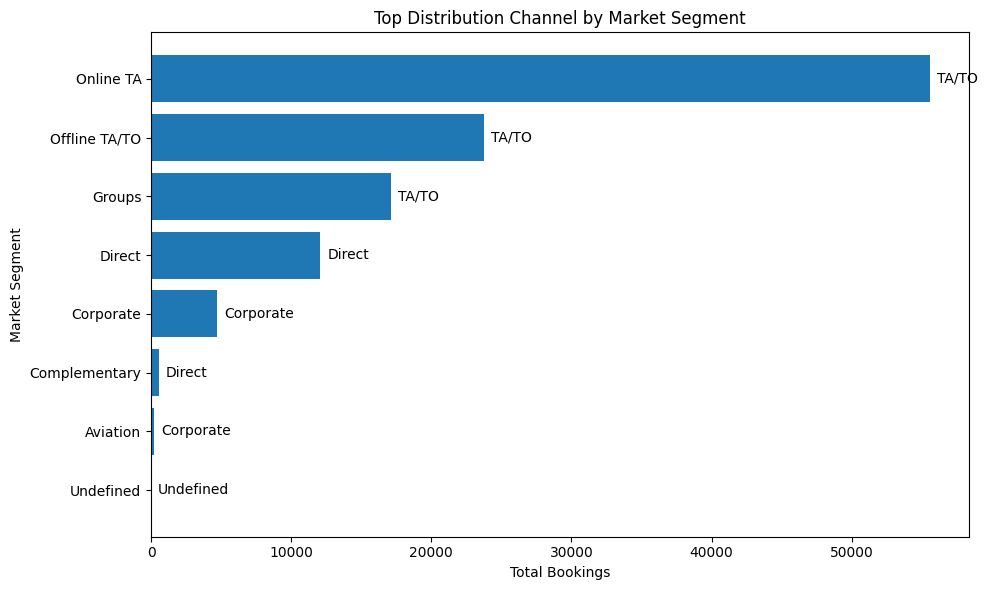

In [14]:
import matplotlib.pyplot as plt

result = spark.sql("""
WITH channel_stats AS
(
    SELECT
        market_segment,
        distribution_channel,
        COUNT(*) total_booking
    FROM hotel_bookings
    GROUP BY market_segment, distribution_channel
)

SELECT *
FROM
(
    SELECT *,
           ROW_NUMBER()
           OVER
           (
               PARTITION BY market_segment
               ORDER BY total_booking DESC
           ) rn
    FROM channel_stats
) x
WHERE rn=1;
""")

pdf = result.toPandas()

pdf = pdf.sort_values('total_booking', ascending=True)

plt.figure(figsize=(10,6))

bars = plt.barh(
    pdf['market_segment'],
    pdf['total_booking']
)

plt.title('Top Distribution Channel by Market Segment')
plt.xlabel('Total Bookings')
plt.ylabel('Market Segment')

# Add channel labels
for i, row in enumerate(pdf.itertuples()):
    plt.text(
        row.total_booking + 500,
        i,
        row.distribution_channel,
        va='center'
    )

plt.tight_layout()
plt.show()

## 9. Khách quay lại có thực sự trung thành hơn?

In [13]:
spark.sql("""
SELECT
    CASE
       WHEN is_repeated_guest = 1
       THEN 'Repeated'
       ELSE 'New'
    END guest_type,

    COUNT(*) total_booking,

    ROUND(
        AVG(is_canceled)*100,
        2
    ) cancel_rate

FROM hotel_bookings

GROUP BY is_repeated_guest;
""").show()

+----------+-------------+-----------+
|guest_type|total_booking|cancel_rate|
+----------+-------------+-----------+
|  Repeated|         3185|      16.23|
|       New|       115136|      37.83|
+----------+-------------+-----------+



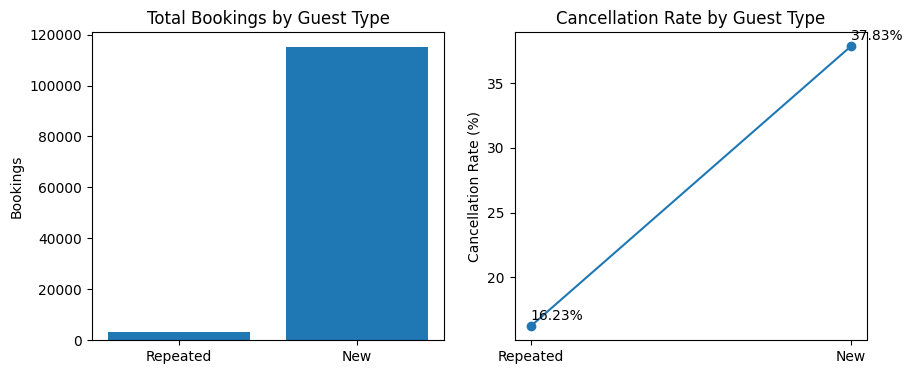

In [25]:
result = spark.sql("""
SELECT
    CASE
       WHEN is_repeated_guest = 1
       THEN 'Repeated'
       ELSE 'New'
    END guest_type,

    COUNT(*) total_booking,

    ROUND(
        AVG(is_canceled)*100,
        2
    ) cancel_rate

FROM hotel_bookings

GROUP BY is_repeated_guest;
""")

import matplotlib.pyplot as plt

pdf = result.toPandas()

fig, axes = plt.subplots(figsize=(10,4), ncols = 2)

axes[0].bar(pdf['guest_type'], pdf['total_booking'])
axes[0].set_title('Total Bookings by Guest Type')
axes[0].set_ylabel('Bookings')

axes[1].plot(pdf['guest_type'], pdf['cancel_rate'], marker='o')
axes[1].set_title('Cancellation Rate by Guest Type')
axes[1].set_ylabel('Cancellation Rate (%)')

for _, row in pdf.iterrows():
    axes[1].text(
        row['guest_type'],
        row['cancel_rate'] + 0.5,
        f"{row['cancel_rate']}%"
    )

plt.show()


## 11. Lead Time trung bình theo loại khách và xếp hạng

In [14]:
spark.sql("""
WITH lead_stats AS
(
    SELECT
        customer_type,
        AVG(lead_time) avg_lead_time
    FROM hotel_bookings
    GROUP BY customer_type
)

SELECT *,
       DENSE_RANK()
       OVER
       (
           ORDER BY avg_lead_time DESC
       ) ranking
FROM lead_stats;
""").show()

26/06/13 05:32:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 05:32:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 05:32:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 05:32:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 05:32:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/13 05:32:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------------+------------------+-------+
|  customer_type|     avg_lead_time|ranking|
+---------------+------------------+-------+
|       Contract|143.40675875678343|      1|
|Transient-Party| 137.4320051362305|      2|
|      Transient| 93.75492713471631|      3|
|          Group| 47.08695652173913|      4|
+---------------+------------------+-------+



26/06/14 16:02:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 16:02:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 16:02:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 16:02:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 16:02:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 16:02:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/14 1

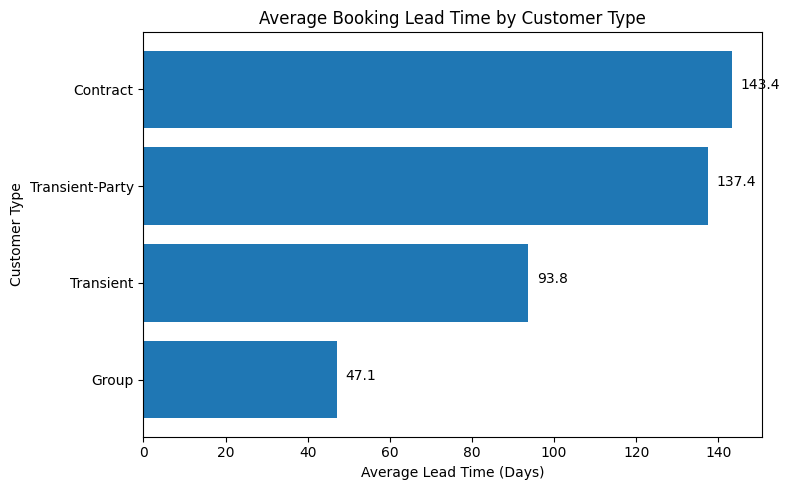

In [26]:
result = spark.sql("""
WITH lead_stats AS
(
    SELECT
        customer_type,
        AVG(lead_time) avg_lead_time
    FROM hotel_bookings
    GROUP BY customer_type
)

SELECT *,
       DENSE_RANK()
       OVER
       (
           ORDER BY avg_lead_time DESC
       ) ranking
FROM lead_stats;
""")

pdf = result.toPandas()

import matplotlib.pyplot as plt

pdf = result.toPandas()

pdf = pdf.sort_values('avg_lead_time')

plt.figure(figsize=(8,5))

plt.barh(
    pdf['customer_type'],
    pdf['avg_lead_time']
)

plt.xlabel('Average Lead Time (Days)')
plt.ylabel('Customer Type')
plt.title('Average Booking Lead Time by Customer Type')

for i, v in enumerate(pdf['avg_lead_time']):
    plt.text(v + 2, i, f'{v:.1f}')

plt.tight_layout()
plt.show()